In [18]:
# =========================
# 1. Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# =========================
# 2. Import Library
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# =========================
# 3. Path File
# =========================
# Input
# input_path  = "/content/drive/My Drive/skripsi/dataset/mbg_2025/final_data/final_mbg_labeled.csv"
input_path  = "/content/drive/My Drive/skripsi/dataset/mbg_2025/final_data/raw_sample_labeled_mbg.csv"

# Outputs
# output_path_sentimen = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_sentimen.png"
# output_path_keyword = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_keyword.png"
# output_path_token = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token.png"

output_path_sentimen = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_sentimen_sample_labeled.png"
output_path_keyword = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_keyword_sample_labeled.png"
output_path_token = "/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_sample_labeled.png"

In [21]:
# =========================
# 4. Load Dataset
# =========================
df = pd.read_csv(input_path, encoding_errors='ignore')
df.head()

,id_str,created_at,period,period_label,full_text,word_count,username,user_id_str,favorite_count,retweet_count,reply_count,quote_count,lang,location,source_keyword,label,label_roberta,annotator_notes
0,1876072984299143507,2025-01-06 01:07:09+00:00,2025-01,Bulan_1,"@HisyamMochtar Menurut saya untuk NU, Muhammad...",31,indragoenawan,22905571,1,0,0,0,in,NaN,mbg,neutral,NaN,NaN
1,1876079950631174330,2025-01-06 01:34:50+00:00,2025-01,Bulan_1,Program unggulan pemerintahan Prabowo Subianto...,34,digitripx_media,1748273723432730624,0,0,0,0,in,NaN,mbg,neutral,NaN,NaN
2,1876080436663005231,2025-01-06 01:36:46+00:00,2025-01,Bulan_1,Bakal Segera Berjalan Dua Program Pemerintahan...,18,keuangannews_id,1226436091617505281,2,1,0,0,in,NaN,mbg,neutral,NaN,NaN
3,1876082320169713871,2025-01-06 01:44:15+00:00,2025-01,Bulan_1,#live \n\nSedang berlangsung Wawancara dialog ...,30,RRIPrograma3,1129936609,0,0,0,0,in,NaN,mbg,neutral,NaN,NaN
4,1876082352214155659,2025-01-06 01:44:23+00:00,2025-01,Bulan_1,Besok Program Makan Bergizi Gratis Wilayah Kal...,25,KaltaraTribun,1689503322070470656,0,0,0,0,in,NaN,mbg,neutral,NaN,NaN



💾 Chart Sentimen berhasil disimpan di:
/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_sentimen_sample_labeled.png


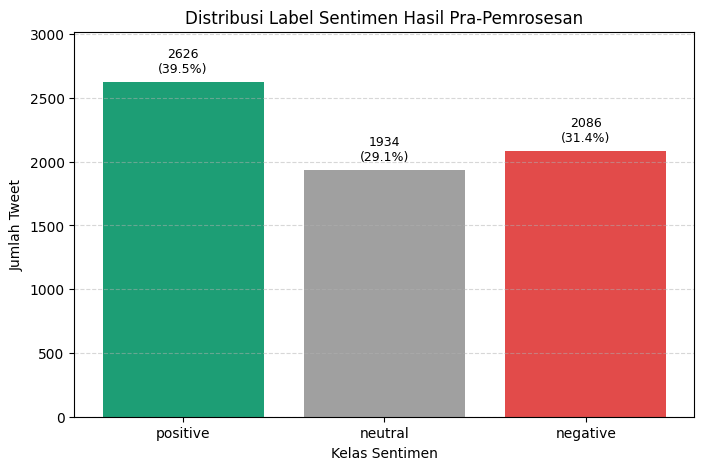

In [22]:
# =========================
# 5. Visualisasi Distribusi Sentimen
# =========================
if 'label' not in df.columns:
    raise ValueError("❌ Kolom 'label' tidak ditemukan")

# Cleaning Label
df['label'] = df['label'].astype(str).str.strip().str.lower()
valid_labels = ['positive', 'neutral', 'negative']
df_sentimen = df[df['label'].isin(valid_labels)]

# Hitung Distribusi
order = ['positive', 'neutral', 'negative']
label_counts = df_sentimen['label'].value_counts().reindex(order, fill_value=0)
total = label_counts.sum()

# Color Mapping
color_map = {
    'positive': '#1D9E75',
    'negative': '#E24B4A',
    'neutral' : '#A0A0A0'
}
colors = [color_map[label] for label in label_counts.index]

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 5))

bars = plt.bar(
    label_counts.index,
    label_counts.values,
    color=colors
)

# Judul & Label
plt.title("Distribusi Label Sentimen Hasil Pra-Pemrosesan", fontsize=12)
plt.xlabel("Kelas Sentimen", fontsize=10)
plt.ylabel("Jumlah Tweet", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# =========================
# Annotation
# =========================
offset = max(label_counts.values) * 0.02

for bar in bars:
    height = bar.get_height()

    if height > 0:
        percentage = (height / total) * 100

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{int(height)}\n({percentage:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=9
        )

# =========================
# TAMBAH SPACE ATAS
# =========================
max_height = max(label_counts.values)
plt.ylim(0, max_height * 1.15)  # tambah 15% ruang atas

# =========================
# Save
# =========================
fig = plt.gcf()

fig.savefig(
    output_path_sentimen,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

print(f"\n💾 Chart Sentimen berhasil disimpan di:\n{output_path_sentimen}")
plt.show()


📊 Summary Distribusi Kata Kunci:
Total Data (Valid Keyword): 6646
- MBG                  : 3473 (52.3%)
- Makan Bergizi Gratis : 3173 (47.7%)

💾 Pie Chart Keyword berhasil disimpan di:
/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_keyword_sample_labeled.png


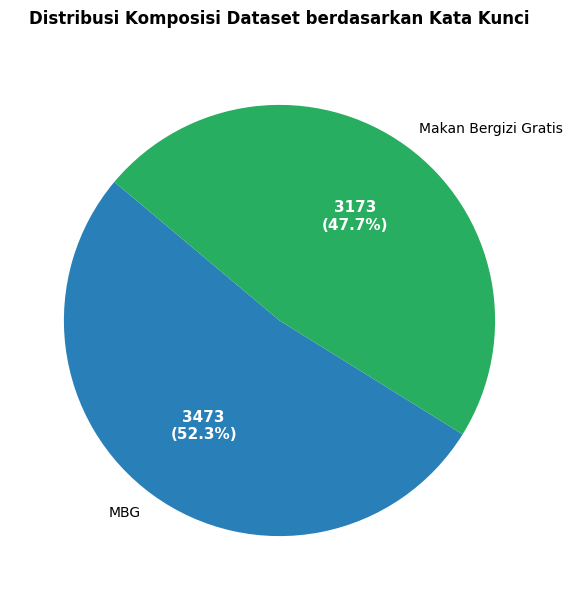

In [23]:
# =========================
# 6. Visualisasi Komposisi Keyword (Pie Chart)
# =========================
if 'source_keyword' in df.columns:
    valid_keywords = ['mbg', 'makan_bergizi_gratis']
    df_keyword = df[df['source_keyword'].astype(str).str.lower().isin(valid_keywords)].copy()

    keyword_map = {
        'mbg': 'MBG',
        'makan_bergizi_gratis': 'Makan Bergizi Gratis'
    }
    df_keyword['keyword_label'] = df_keyword['source_keyword'].astype(str).str.lower().map(keyword_map)
    keyword_counts = df_keyword['keyword_label'].value_counts()

    # --- Psikologi Warna ---
    # Makan Bergizi Gratis: Hijau (Kesehatan/Nutrisi)
    # MBG: Biru (Kepercayaan/Instansi)
    color_dict = {'Makan Bergizi Gratis': '#27ae60', 'MBG': '#2980b9'}
    pie_colors = [color_dict[label] for label in keyword_counts.index]

    # Fungsi custom untuk menampilkan <total_data>\n(<presentase>) di dalam chart
    def func_label(pct, allvals):
        absolute = int(round(pct/100.*sum(allvals)))
        return f"{absolute:d}\n({pct:.1f}%)"

    plt.figure(figsize=(8, 7))

    # Membuat Pie Chart
    wedges, texts, autotexts = plt.pie(
        keyword_counts.values,
        labels=keyword_counts.index,      # Label kategori di samping chart
        autopct=lambda pct: func_label(pct, keyword_counts.values), # Label data di dalam chart
        startangle=140,
        colors=pie_colors,
        labeldistance=1.1,               # Jarak label kategori samping (sedikit di luar)
        textprops={'fontsize': 10, 'fontweight': 'normal'}
    )

    # Mengatur style teks di dalam chart agar lebih terbaca (Putih & Bold)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(11)

    # Judul Chart
    plt.title("Distribusi Komposisi Dataset berdasarkan Kata Kunci", fontsize=12, pad=20, fontweight='bold')

    # Menyimpan Grafik
    fig = plt.gcf()
    fig.savefig(
        output_path_keyword,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    # =========================
    # Data Summary Output
    # =========================
    total_data = keyword_counts.sum()
    count_mbg = keyword_counts.get('MBG', 0)
    count_mbg_gratis = keyword_counts.get('Makan Bergizi Gratis', 0)

    pct_mbg = (count_mbg / total_data) * 100 if total_data > 0 else 0
    pct_mbg_gratis = (count_mbg_gratis / total_data) * 100 if total_data > 0 else 0

    print("\n📊 Summary Distribusi Kata Kunci:")
    print(f"Total Data (Valid Keyword): {total_data}")
    print(f"- MBG                  : {count_mbg} ({pct_mbg:.1f}%)")
    print(f"- Makan Bergizi Gratis : {count_mbg_gratis} ({pct_mbg_gratis:.1f}%)")

    print(f"\n💾 Pie Chart Keyword berhasil disimpan di:\n{output_path_keyword}")
    plt.show()
else:
    print("❌ Kolom 'source_keyword' tidak ditemukan.")


💾 Histogram Token berhasil disimpan di:
/content/drive/My Drive/skripsi/dataset/mbg_2025/processed/eksplorasi/chart_distribusi_token_sample_labeled.png


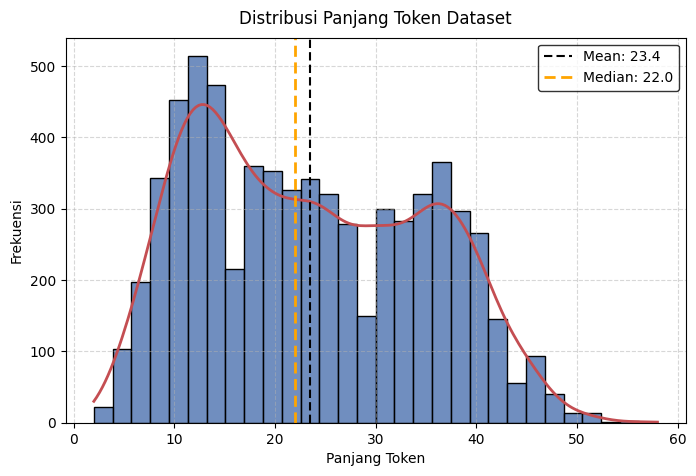

In [24]:
# =========================
# 7. Visualisasi Distribusi Panjang Token
# =========================
if 'full_text' in df.columns:
    # Menghitung panjang token dari kolom original raw 'full_text'
    df['token_length'] = df['full_text'].astype(str).apply(lambda x: len(x.split()))

    # Menghitung nilai Mean dan Median
    mean_val = df['token_length'].mean()
    median_val = df['token_length'].median()

    plt.figure(figsize=(8, 5))

    # Plotting menggunakan Seaborn untuk bentuk chart dan kurva KDE
    ax = sns.histplot(
        df['token_length'],
        kde=True,
        color='#4C72B0',
        alpha=0.8,
        bins=30
    )

    # Menyesuaikan warna garis kurva densitas (KDE)
    if ax.lines:
        ax.lines[0].set_color('#C44E52')
        ax.lines[0].set_linewidth(2)

    # Menambahkan garis vertikal untuk Mean dan Median
    # linestyle=(0, (6, 6)) membuat garis putus-putus lebih lebar dari default, tapi tidak terlalu renggang
    plt.axvline(
        mean_val,
        color='black',
        linestyle=(0, (4, 2)),
        linewidth=1.5,
        label=f'Mean: {mean_val:.1f}'
    )
    plt.axvline(
        median_val,
        color='#FFA500',
        linestyle=(0, (4, 2)),
        linewidth=2,
        label=f'Median: {median_val:.1f}'
    )

    # Judul & Label
    plt.title("Distribusi Panjang Token Dataset", fontsize=12, pad=10)
    plt.xlabel("Panjang Token", fontsize=10)
    plt.ylabel("Frekuensi", fontsize=10)

    # Menambahkan grid pada sumbu Y (horizontal) dan X (vertikal) dengan garis putus-putus
    plt.grid(axis='both', linestyle='--', alpha=0.5)

    # Menambahkan Legend untuk garis Mean dan Median (di pojok kanan atas)
    plt.legend(
        loc='upper right',
        fontsize=10,
        frameon=True,
        edgecolor='black'
    )

    # =========================
    # Save
    # =========================
    fig = plt.gcf()

    fig.savefig(
        output_path_token,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    print(f"\n💾 Histogram Token berhasil disimpan di:\n{output_path_token}")
    plt.show()
else:
    print("❌ Kolom 'full_text' tidak ditemukan. Pastikan nama kolom benar.")